Objective:

This notebook trains and evaluates multiple machine learning models for predicting lead conversion.

The feature audit and feature engineering phases have already been completed in:

- 01_data_understanding.ipynb
- 02_feature_engineering.ipynb

The objectives of this notebook are:

1. Establish a baseline model.
2. Train multiple classification models.
3. Compare model performance.
4. Evaluate models using appropriate classification metrics.
5. Select the best candidate model.
6. Analyze model performance from a business perspective.

Important principle:

Model selection will not be based on accuracy alone.

Because this is a lead-scoring problem, the ability to identify high-potential leads and support sales prioritization is also important.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)

In [3]:
# Define project paths

project_root = Path.cwd().parent

data_path = project_root / "data" / "raw" / "Lead Scoring.csv"

# Load dataset

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9240, 37)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [4]:
candidate_features = [
    "Lead Origin",
    "Lead Source",
    "Country",
    "Specialization",
    "How did you hear about X Education",
    "What is your current occupation",
    "What matters most to you in choosing a course",
    "Lead Profile",
    "City",
    "Do Not Email",
    "A free copy of Mastering The Interview",
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit"
]

target = "Converted"

X = df[candidate_features].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nConversion rate:")
print(y.mean().round(4))

Feature matrix shape: (9240, 14)
Target shape: (9240,)

Target distribution:
Converted
0    5679
1    3561
Name: count, dtype: int64

Conversion rate:
0.3854


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining conversion rate:", round(y_train.mean(), 4))
print("Testing conversion rate:", round(y_test.mean(), 4))

Training shape: (7392, 14)
Testing shape: (1848, 14)

Training conversion rate: 0.3854
Testing conversion rate: 0.3853


## Feature Groups

The candidate features selected during the feature audit are divided into numerical and categorical groups.

This separation is important because different types of features require different preprocessing steps:

- **Numerical features** will be imputed and scaled.
- **Categorical features** will be imputed and encoded.

The transformations will later be combined into a single reusable preprocessing pipeline.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [7]:
# Numerical features that represent website engagement
numerical_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit"
]

# Categorical and binary features selected during the feature audit
categorical_features = [
    "Lead Origin",
    "Lead Source",
    "Country",
    "Specialization",
    "How did you hear about X Education",
    "What is your current occupation",
    "What matters most to you in choosing a course",
    "Lead Profile",
    "City",
    "Do Not Email",
    "A free copy of Mastering The Interview"
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 3
Categorical features: 11


## Numerical Feature Preprocessing

The numerical features contain missing values, particularly:

- `TotalVisits`
- `Page Views Per Visit`

Missing numerical values will be replaced using the **median** calculated from the training data.

Median imputation is preferred because some engagement features contain extreme values and are right-skewed.

After imputation, the numerical features will be standardized using `StandardScaler`.

The scaler will be fitted only on the training data to prevent information leakage.

In [8]:
# Preprocessing pipeline for numerical features
numerical_pipeline = Pipeline(steps=[
    
    # Replace missing values using the median learned from training data
    ("imputer", SimpleImputer(strategy="median")),
    
    # Standardize numerical features
    ("scaler", StandardScaler())
])

## Categorical Feature Preprocessing

Several categorical features contain missing values.

Missing values will be replaced with the explicit category:

`Missing`

This preserves potentially useful information because the feature audit showed that missingness itself may be associated with different conversion behavior.

Categorical features will then be transformed using One-Hot Encoding.

`handle_unknown="ignore"` is used so that the deployed model can safely process new categories that were not present in the training data.

In [9]:
# Preprocessing pipeline for categorical features
categorical_pipeline = Pipeline(steps=[
    
    # Replace missing categorical values with an explicit category
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    
    # Convert categorical values into numerical indicator columns
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

## Combined Preprocessing Pipeline

`ColumnTransformer` allows different preprocessing pipelines to be applied to different groups of features.

The final preprocessing workflow is:

Raw Features

↓

Numerical Features → Imputation → Scaling

Categorical Features → Imputation → One-Hot Encoding

↓

Model-Ready Feature Matrix

At this stage, only the selected features are retained.

In [10]:
# Apply the appropriate preprocessing pipeline to each feature group
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    
    # Drop any columns that are not explicitly included
    remainder="drop"
)

## Website Engagement Missingness Feature

During feature engineering, we discovered that `TotalVisits` and `Page Views Per Visit` are missing together for the same 137 leads.

The missingness pattern also showed a substantial difference in historical conversion rates:

- Non-missing engagement information → approximately 38% conversion
- Missing engagement information → approximately 73% conversion

Therefore, we will preserve this information by creating a binary feature:

`Website_Engagement_Missing`

The feature will indicate whether the website engagement metrics are missing for a lead.

- `0` → engagement information is available
- `1` → engagement information is missing

This feature must be created inside the reusable pipeline so that the same transformation is automatically applied during training, evaluation, and deployment.

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin

In [17]:
class LeadFeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    """
    Applies business-oriented feature engineering rules before
    column-based preprocessing.
    """

    def fit(self, X, y=None):
        """
        No parameters are learned from the data because the current
        transformations are based on predefined business rules.
        """
        return self

    def transform(self, X):
        """
        Apply category cleaning and create engineered features.
        """

        # Create a copy to avoid modifying the original input data
        X = X.copy()

        # ---------------------------------------------------------
        # 1. Lead Source Cleaning
        # ---------------------------------------------------------

        # Normalize inconsistent capitalization
        X["Lead Source"] = X["Lead Source"].replace({
            "google": "Google",
            "bing": "Bing"
        })

        # Group extremely rare Lead Source categories into "Other"
        rare_lead_sources = [
            "Click2call",
            "Social Media",
            "Live Chat",
            "Press_Release",
            "blog",
            "Pay per Click Ads",
            "WeLearn",
            "welearnblog_Home",
            "youtubechannel",
            "testone",
            "NC_EDM",
            "Bing"
        ]

        X["Lead Source"] = X["Lead Source"].replace(
            rare_lead_sources,
            "Other"
        )

        # ---------------------------------------------------------
        # 2. Current Occupation Cleaning
        # ---------------------------------------------------------

        # Consolidate very small occupation categories
        X["What is your current occupation"] = X[
            "What is your current occupation"
        ].replace({
            "Businessman": "Other",
            "Housewife": "Other"
        })

        # ---------------------------------------------------------
        # 3. Lead Profile Cleaning
        # ---------------------------------------------------------

        # Consolidate very small Lead Profile categories
        X["Lead Profile"] = X["Lead Profile"].replace({
            "Lateral Student": "Other",
            "Dual Specialization Student": "Other"
        })

        # ---------------------------------------------------------
        # 4. Website Engagement Missingness
        # ---------------------------------------------------------

        # Create a binary indicator because TotalVisits and
        # Page Views Per Visit were found to be missing together
        X["Website_Engagement_Missing"] = (
            X["TotalVisits"].isna()
            & X["Page Views Per Visit"].isna()
        ).astype(int)

        return X

## Adding the Engineered Feature

The custom transformer creates:

`Website_Engagement_Missing`

This engineered feature is binary and will be processed separately from the numerical and categorical features.

The final preprocessing pipeline will therefore contain:

- 3 numerical features
- 11 categorical features
- 1 engineered binary feature

In [13]:
# Engineered binary feature created by the custom transformer
binary_features = [
    "Website_Engagement_Missing"
]

print("Binary features:", len(binary_features))


Binary features: 1


## Final Preprocessing Architecture

The preprocessing workflow contains two stages.

### Stage 1: Custom Feature Engineering

The `WebsiteEngagementMissingTransformer` adds the feature:

`Website_Engagement_Missing`

This feature captures whether the two website engagement metrics are missing.

### Stage 2: Column-Based Preprocessing

After feature engineering, the appropriate transformations are applied to each feature type:

- Numerical features → median imputation and standardization
- Categorical features → missing-value handling and one-hot encoding
- Binary features → passed through without additional transformation

The complete preprocessing workflow is placed inside a single reusable scikit-learn pipeline.

This ensures that the same transformations are automatically applied during:

- model training
- model evaluation
- prediction on new leads
- deployment

In [18]:
# Apply the appropriate preprocessing pipeline to each feature group
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    
    # Drop any columns that are not explicitly included
    remainder="drop"
)

In [21]:
# Complete feature engineering and preprocessing pipeline
feature_pipeline = Pipeline(steps=[
    
    # Apply business-oriented feature engineering
    (
        "feature_engineering",
        LeadFeatureEngineeringTransformer()
    ),
    
    # Apply preprocessing based on feature type
    (
        "preprocessing",
        preprocessor
    )
])

## Pipeline Validation

Before training models, we validate the complete feature engineering pipeline.

The pipeline will be fitted using only the training data and then used to transform both training and testing data.

This validation step confirms that:

1. The custom engineered feature is created successfully.
2. Numerical features are processed correctly.
3. Categorical features are encoded correctly.
4. The training and testing datasets produce compatible feature spaces.
5. No information from the test set is used to learn preprocessing parameters.

In [23]:
# Fit the pipeline using only the training data
X_train_processed = feature_pipeline.fit_transform(X_train)

# Apply the fitted pipeline to the test data
X_test_processed = feature_pipeline.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (7392, 113)
Processed testing shape: (1848, 113)


# Baseline Model Training

## Objective

The preprocessing pipeline has been validated successfully.

The next step is to train multiple baseline machine learning models and compare their performance on the lead conversion prediction problem.

The initial models selected are:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

These models provide a combination of:

- interpretability
- nonlinear learning capability
- ensemble methods
- strong baseline performance

Each model will be combined with the preprocessing pipeline to create a complete machine learning workflow.

This ensures that the same preprocessing transformations are applied consistently during both training and prediction.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [25]:
baseline_models = {
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

## Baseline Model Evaluation

Each model will be combined with the same preprocessing pipeline.

The models will be trained using the training dataset and evaluated on the unseen test dataset.

The following metrics will be used:

- **Accuracy** — overall proportion of correct predictions
- **Precision** — how often predicted conversions are actually converted leads
- **Recall** — how many actual converted leads are correctly identified
- **F1 Score** — balance between precision and recall
- **ROC-AUC** — ability to distinguish between converted and non-converted leads across different classification thresholds

Since this project is a lead-scoring system, we will not select the final model based on accuracy alone. The business objective is to identify high-quality leads effectively while maintaining reliable overall performance.

In [26]:
results = []

trained_models = {}

for model_name, model in baseline_models.items():
    
    print(f"Training {model_name}...")
    
    # Create complete pipeline
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", feature_pipeline),
            ("model", model)
        ]
    )
    
    # Train model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Prediction probabilities
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]
    
    # Store trained model
    trained_models[model_name] = model_pipeline
    
    # Calculate evaluation metrics
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

print("\nAll baseline models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

All baseline models trained successfully.


## Model Comparison

The baseline models have been trained successfully.

The next step is to compare their performance using the evaluation metrics calculated on the unseen test dataset.

The comparison will focus on:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The results will help identify the strongest candidate models for further evaluation and potential hyperparameter tuning.

In [27]:
# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort models by ROC-AUC
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

# Display results
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.801948,0.766975,0.698034,0.730882,0.874986
1,Logistic Regression,0.792749,0.765751,0.665730,0.712246,0.865548
2,Random Forest,0.783550,0.746835,0.662921,0.702381,0.860994
3,Decision Tree,0.755952,0.692762,0.658708,0.675306,0.740207


## Detailed Evaluation of Top Baseline Models

Based on the baseline comparison, the three strongest models are:

- Gradient Boosting
- Logistic Regression
- Random Forest

These models will now be evaluated in more detail using:

- Confusion matrices
- Classification reports
- ROC-AUC analysis

This evaluation will provide a clearer understanding of the trade-offs between correctly identifying converted leads and incorrectly prioritizing non-converting leads.

### Gradient Boosting Evaluation

Gradient Boosting achieved the strongest overall performance among the baseline models.

We will now examine its predictions in more detail using:

- Confusion Matrix
- Classification Report
- ROC-AUC Score

This helps us understand not only the overall model performance, but also the types of prediction errors the model makes.

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

# Select the trained Gradient Boosting pipeline
gb_model = trained_models["Gradient Boosting"]

# Generate predictions
gb_pred = gb_model.predict(X_test)

# Generate conversion probabilities
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, gb_pred))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, gb_pred))

# ROC-AUC
print("\nROC-AUC Score:")
print(round(roc_auc_score(y_test, gb_prob), 4))

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1136
           1       0.77      0.70      0.73       712

    accuracy                           0.80      1848
   macro avg       0.79      0.78      0.79      1848
weighted avg       0.80      0.80      0.80      1848


Confusion Matrix:

[[985 151]
 [215 497]]

ROC-AUC Score:
0.875


### Evaluation of Logistic Regression and Random Forest

Gradient Boosting produced the strongest baseline performance.

Logistic Regression and Random Forest also achieved strong results and will be evaluated using the same detailed metrics.

Comparing the models in detail will help determine which models should proceed to the hyperparameter tuning stage.

In [29]:
top_models = [
    "Logistic Regression",
    "Random Forest"
]

for model_name in top_models:
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    model = trained_models[model_name]
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))
    
    # ROC-AUC
    print("\nROC-AUC Score:")
    print(round(roc_auc_score(y_test, y_prob), 4))
    print()

Logistic Regression

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1136
           1       0.77      0.67      0.71       712

    accuracy                           0.79      1848
   macro avg       0.79      0.77      0.78      1848
weighted avg       0.79      0.79      0.79      1848


Confusion Matrix:

[[991 145]
 [238 474]]

ROC-AUC Score:
0.8655

Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1136
           1       0.75      0.66      0.70       712

    accuracy                           0.78      1848
   macro avg       0.77      0.76      0.77      1848
weighted avg       0.78      0.78      0.78      1848


Confusion Matrix:

[[976 160]
 [240 472]]

ROC-AUC Score:
0.861



======================================================================
Logistic Regression
======================================================================

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1136
           1       0.77      0.67      0.71       712

    accuracy                           0.79      1848
   macro avg       0.79      0.77      0.78      1848
weighted avg       0.79      0.79      0.79      1848


Confusion Matrix:

[[991 145]
 [238 474]]

ROC-AUC Score:
0.8655

======================================================================
Random Forest
======================================================================

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1136
           1       0.75      0.66      0.70       712

    accuracy                           0.78      1848
   macro avg       0.77      0.76      0.77      1848
weighted avg       0.78      0.78      0.78      1848


Confusion Matrix:

[[976 160]
 [240 472]]

ROC-AUC Score:
0.861

<Figure size 1000x700 with 0 Axes>

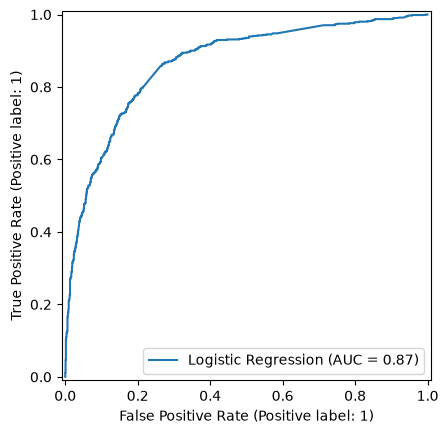

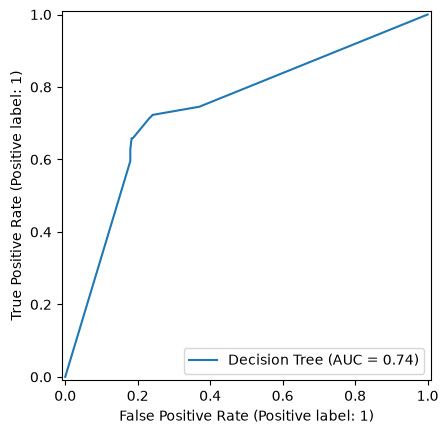

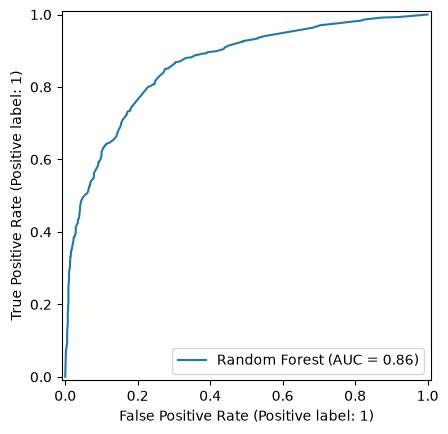

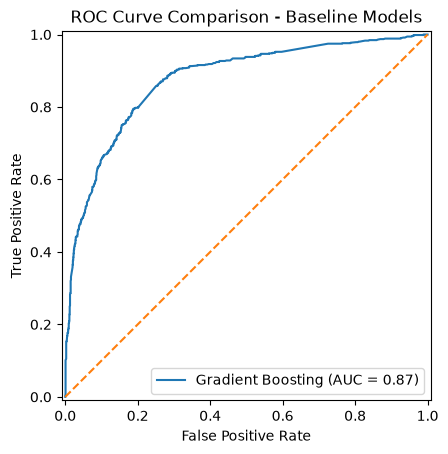

In [30]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for model_name, model in trained_models.items():
    
    # Get conversion probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Plot ROC curve
    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison - Baseline Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

### ROC Curve Interpretation

The ROC curve comparison confirms the quantitative results obtained from the baseline evaluation.

Gradient Boosting demonstrates the strongest overall ability to distinguish between converted and non-converted leads, with the highest ROC-AUC score.

Logistic Regression performs competitively and provides a strong interpretable benchmark.

Random Forest performs reasonably well but does not outperform Gradient Boosting or Logistic Regression.

Decision Tree shows comparatively weaker discriminatory performance.

Based on these results, Gradient Boosting will proceed as the primary model candidate for hyperparameter tuning, while Logistic Regression will be retained as an interpretable baseline model.

## Hyperparameter Tuning — Gradient Boosting

Gradient Boosting achieved the strongest performance among the baseline models.

The next step is to improve the model by tuning its hyperparameters.

Hyperparameter tuning will use cross-validation so that model configurations are evaluated across multiple training subsets rather than relying on a single train-validation split.

The primary optimization metric will be ROC-AUC because the lead-scoring system is designed to estimate and rank leads according to their probability of conversion.

The test set will not be used during hyperparameter tuning. It will remain untouched until final model evaluation.

In [31]:
from sklearn.model_selection import GridSearchCV

# Gradient Boosting model
gb_model = GradientBoostingClassifier(
    random_state=42
)

# Hyperparameter combinations
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5]
}

# Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train and search for the best configuration
grid_search.fit(
    X_train_processed,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation ROC-AUC:
0.8923


In [32]:
{
    'learning_rate': 0.1,
    'max_depth': 3,
    'min_samples_split': 5,
    'n_estimators': 200
}

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_samples_split': 5,
 'n_estimators': 200}

### Best Hyperparameters

The GridSearchCV process evaluated 16 Gradient Boosting configurations using 5-fold cross-validation.

The best configuration was:

- `n_estimators = 200`
- `learning_rate = 0.1`
- `max_depth = 3`
- `min_samples_split = 5`

The best cross-validation ROC-AUC score was **0.8923**.

This configuration will now be evaluated on the untouched test set.

The test set was not used during hyperparameter tuning and therefore provides an independent evaluation of the tuned model.

In [33]:
# Retrieve the best tuned Gradient Boosting model
best_gb_model = grid_search.best_estimator_

# Predictions on the untouched test set
y_pred_tuned = best_gb_model.predict(X_test_processed)

# Conversion probabilities
y_prob_tuned = best_gb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Gradient Boosting Performance")
print("=" * 50)

print(f"Accuracy:  {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1 Score:  {tuned_f1:.4f}")
print(f"ROC-AUC:   {tuned_roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Gradient Boosting Performance
Accuracy:  0.8025
Precision: 0.7657
Recall:    0.7022
F1 Score:  0.7326
ROC-AUC:   0.8736

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1136
           1       0.77      0.70      0.73       712

    accuracy                           0.80      1848
   macro avg       0.79      0.78      0.79      1848
weighted avg       0.80      0.80      0.80      1848


Confusion Matrix:

[[983 153]
 [212 500]]


## Baseline vs Tuned Gradient Boosting

Hyperparameter tuning was performed using 5-fold cross-validation with ROC-AUC as the primary optimization metric.

The best cross-validation configuration achieved a ROC-AUC of **0.8923**.

When evaluated on the untouched test set, the tuned model achieved:

- Accuracy: **0.8025**
- Precision: **0.7657**
- Recall: **0.7022**
- F1 Score: **0.7326**
- ROC-AUC: **0.8736**

Compared with the baseline Gradient Boosting model, the tuned model produced only marginal changes in performance.

The baseline model achieved a slightly higher test ROC-AUC of **0.8750**, while the tuned model achieved slightly higher recall and F1 score.

Because the lead-scoring system primarily uses predicted conversion probabilities to rank leads, ROC-AUC is an important model-selection metric.

Therefore, the baseline Gradient Boosting model will be retained as the primary candidate, while the tuned model results will be documented as evidence that extensive hyperparameter tuning did not provide a meaningful improvement.